# 역대 매달 개수 상위 5위

In [59]:
import pandas as pd

df = pd.read_csv('Olympic_Games_Medal_Tally.csv')

winter_df = df[df['edition'].str.contains('Winter Olympics')]
korea_df = winter_df[winter_df['country_noc'].str.contains('KOR')]

korea_df['rank'] = korea_df['total'].rank(ascending = False, method = 'dense').astype('int')
print('상위 올림픽 랭킹')
print(korea_df[['edition', 'total', 'rank']].sort_values(by = 'rank'))

상위 올림픽 랭킹
                   edition  total  rank
1729  2018 Winter Olympics     17     1
1675  2010 Winter Olympics     14     2
1651  2006 Winter Olympics     11     3
1766  2022 Winter Olympics      9     4
1709  2014 Winter Olympics      8     5
1605  1998 Winter Olympics      6     6
1580  1994 Winter Olympics      6     6
1634  2002 Winter Olympics      4     7
1564  1992 Winter Olympics      4     7


C:\Users\KDS21\AppData\Local\Temp\ipykernel_20236\2249352466.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  korea_df['rank'] = korea_df['total'].rank(ascending = False, method = 'dense').astype('int')


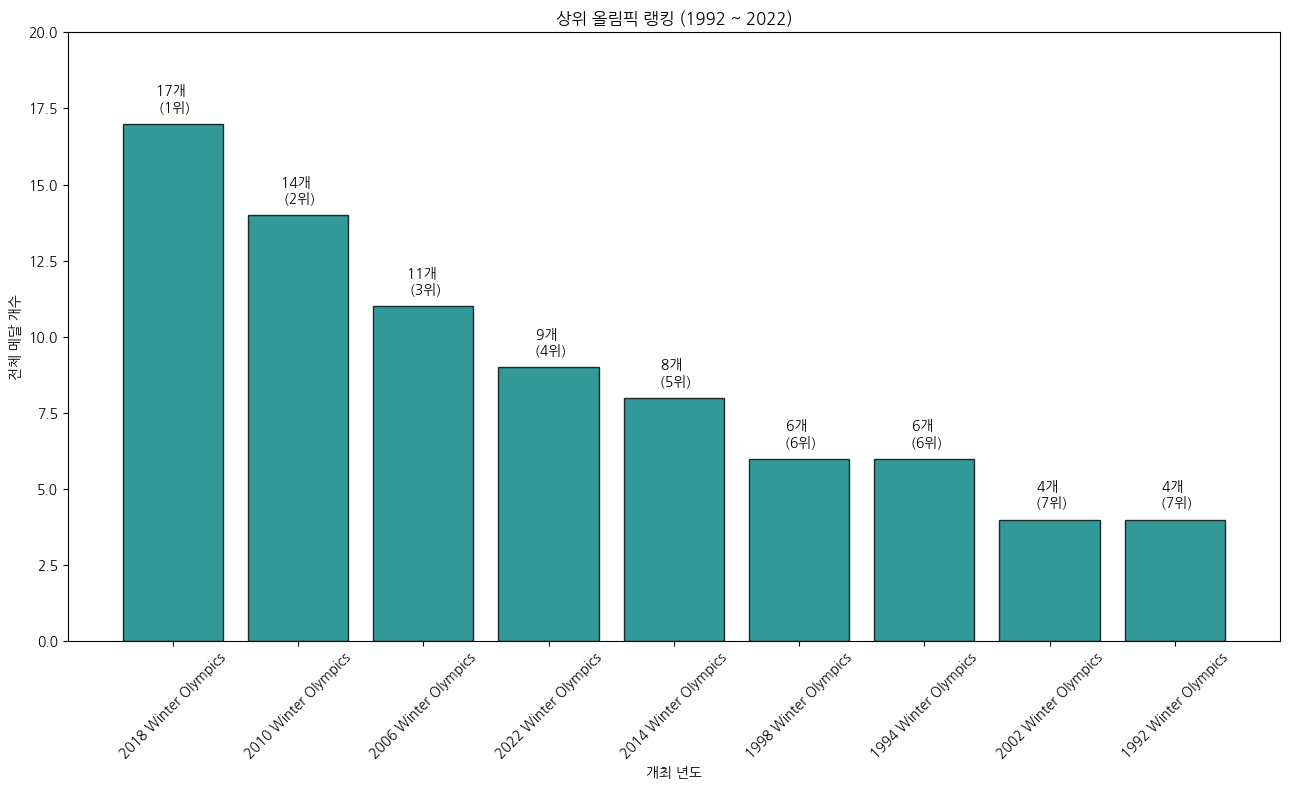

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

data = {'edition' : ['2018 Winter Olympics', '2010 Winter Olympics', '2006 Winter Olympics', '2022 Winter Olympics', '2014 Winter Olympics', '1998 Winter Olympics', '1994 Winter Olympics', '2002 Winter Olympics', '1992 Winter Olympics'],
        'total' : [17, 14, 11, 9, 8, 6, 6, 4, 4],
        'rank' : [1, 2, 3, 4, 5, 6, 6, 7, 7]}
df_rank = pd.DataFrame(data)

plt.figure(figsize = (13, 8))

bars = plt.bar(df_rank['edition'], df_rank['total'], color = 'teal', alpha = 0.8, edgecolor = 'black')

plt.title('상위 올림픽 랭킹 (1992 ~ 2022)')
plt.xlabel('개최 년도')
plt.ylabel('전체 메달 개수')
plt.xticks(rotation = 45)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 0.3, f'{int(height)}개 \n ({df_rank['rank'][i]}위)',
             ha = 'center', va = 'bottom')

plt.ylim(0, 20)
plt.tight_layout()
plt.show()

In [61]:
import pandas as pd

df = pd.read_csv('olympic_results.csv')

korea_df = df[df['country_code'].str.contains('KR', na = False)]

medal_counts = korea_df.groupby(['slug_game', 'medal_type']).size().unstack(fill_value = 0)

medal_counts['total'] = medal_counts.sum(axis = 1)

medal_counts['total_rank'] = medal_counts['total'].rank(ascending = False, method = 'min').astype(int)

print(medal_counts)

medal_type           BRONZE  GOLD  SILVER  total  total_rank
slug_game                                                   
albertville-1992          1     2       1      4          19
athens-2004               9     9      12     30           3
atlanta-1996              5     7      15     27           7
barcelona-1992           12    12       5     29           5
beijing-2008              8    13      11     32           2
beijing-2022              2     2       5      9          14
helsinki-1952             2     0       0      2          22
lillehammer-1994          1     4       1      6          16
london-1948               2     0       0      2          22
london-2012               8    13       9     30           3
los-angeles-1984          7     6       6     19          10
melbourne-1956            1     0       1      2          22
mexico-city-1968          1     0       1      2          22
montreal-1976             4     1       1      6          16
munich-1972             

In [52]:
import pandas as pd

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')

winter_df = df[df['edition'].str.contains('Winter Olympics')]
korea_df = winter_df[winter_df['country_noc'].str.contains('KOR')]

medal_counts = korea_df.groupby(['edition', 'sport', 'event', 'medal']).size().unstack(fill_value = 0)

medal_counts['total'] = medal_counts.sum(axis = 1)

medal_counts['total_rank'] = medal_counts['total'].rank(ascending = False, method = 'min').astype(int)

final_result = medal_counts.reset_index()

target_columns = ['edition', 'sport', 'event', 'total', 'total_rank']

display(final_result[target_columns].sort_values('total_rank').head(10))

# korea_medals = korea_df[korea_df['medal'].notna()].copy()

# korea_df.head()

medal,edition,sport,event,total,total_rank
1,1992 Winter Olympics,Short Track Speed Skating,"5,000 metres Relay, Men",5,1
5,1994 Winter Olympics,Short Track Speed Skating,"3,000 metres Relay, Women",5,1
10,1998 Winter Olympics,Short Track Speed Skating,"3,000 metres Relay, Women",5,1
8,1998 Winter Olympics,Short Track Speed Skating,"5,000 metres Relay, Men",5,1
13,2002 Winter Olympics,Short Track Speed Skating,"3,000 metres Relay, Women",5,1
24,2010 Winter Olympics,Short Track Speed Skating,"5,000 metres Relay, Men",5,1
18,2006 Winter Olympics,Short Track Speed Skating,"3,000 metres Relay, Women",5,1
16,2006 Winter Olympics,Short Track Speed Skating,"5,000 metres Relay, Men",5,1
55,2018 Winter Olympics,Curling,"Curling, Women",5,1
58,2022 Winter Olympics,Short Track Speed Skating,"5,000 metres Relay, Men",5,1


In [56]:
import pandas as pd

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')

winter_df = df[df['edition'].str.contains('Winter Olympics', na=False)]
korea_df = winter_df[winter_df['country_noc'] == 'KOR'].copy()

korea_medals = korea_df[korea_df['medal'].notna()]

top5_sports = korea_medals['sport'].value_counts().head(5)

print("대한민국 동계 올림픽 상위 5개 종목")
print(top5_sports)

대한민국 동계 올림픽 상위 5개 종목
sport
Short Track Speed Skating    101
Speed Skating                 26
Curling                        5
Bobsleigh                      4
Figure Skating                 2
Name: count, dtype: int64


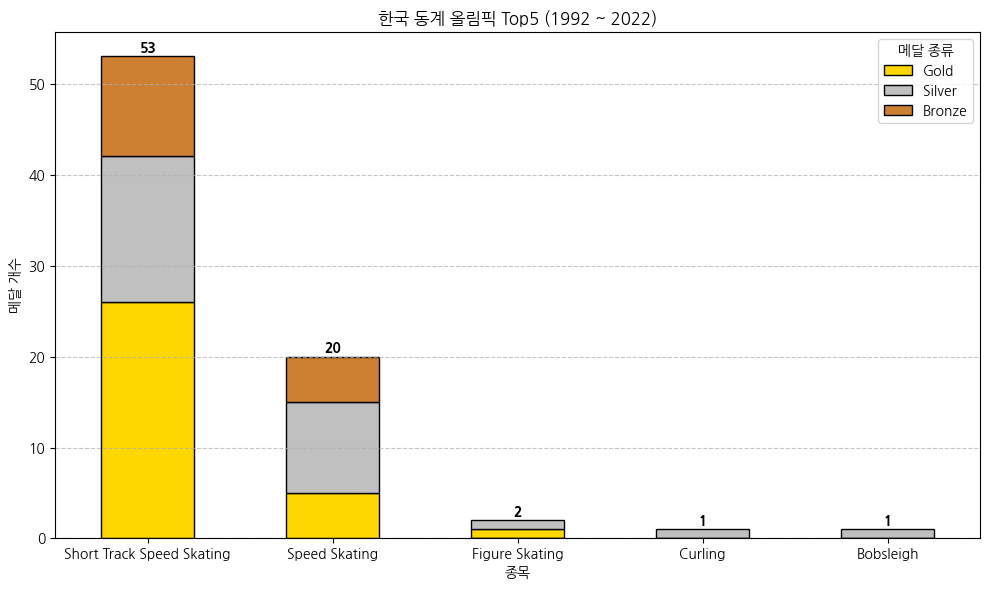

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')

# 한국 동계 올림픽 데이터 필터링
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 메달 획득 데이터만 추출 및 단체전 중복 제거
# 한 경기에 여러 선수가 있어도 메달은 1개로 집계
korea_medals = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])

# 종목별(sport)로 메달 종류(medal) 개수 집계
medal_counts = korea_medals.groupby(['sport', 'medal']).size().unstack(fill_value=0)

# 금, 은, 동 순서 정렬 및 상위 5개 종목 선정 (합계 기준)
medal_counts['total'] = medal_counts.sum(axis=1)
top5_sports = medal_counts.sort_values(by='total', ascending=False).head(5)

# 금, 은, 동 순서로 컬럼 정렬
plot_data = top5_sports[['Gold', 'Silver', 'Bronze']]

# 누적 막대 그래프 그리기
ax = plot_data.plot(kind='bar', stacked=True, color=['#FFD700', '#C0C0C0', '#CD7F32'], figsize=(10, 6), edgecolor='black')

plt.title('한국 동계 올림픽 Top5 (1992 ~ 2022)')
plt.xlabel('종목')
plt.ylabel('메달 개수')
plt.xticks(rotation=0)
plt.legend(title='메달 종류')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 총 합계 숫자 표시
for i, total in enumerate(top5_sports['total']):
    ax.text(i, total + 0.5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()